# 不等式制約の考慮

[ダミー変数による制約](./Inequality_constraint.ipynb)にて制御入力の制約を取り扱った。

このNoteではlogによるバリア関数による制約を検討する。

## バリア関数の再考



$\log$関数は以下のように 正方向から$0$に向かうと急激に値が小さくなっていくものである。また、負の値ではlogは定義されないという性質を持つ。

$$
x \rightarrow 0^+ \Rightarrow \log(x) \rightarrow -\infty
$$

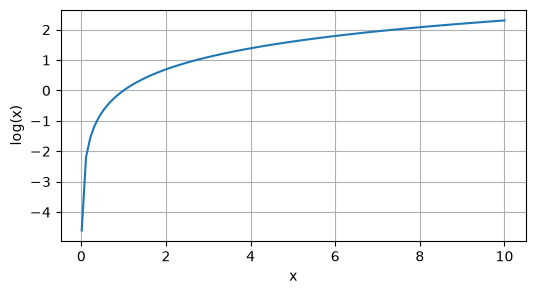

In [10]:
import matplotlib.pyplot as plt
import numpy as np

x_window = np.linspace(0.01, 10, 100)
y_window = np.log(x_window)
fig, ax = plt.subplots(1,1, figsize=(6,3))
ax.plot(x_window, y_window)
ax.grid()
ax.set_xlabel('x')
ax.set_ylabel('log(x)')
plt.show()

不等式制約条件は以下のように制約が負になるように構成されている。そのため$\log(g(x,u))$としてしまうと、値が定義されない、つまり計算できない状況になる。

$$
g(x,u) \le 0
$$

そこで$\log(-g(x,u))$のようにすると、$g$が制約の境界 $0$ に近くなると、$-\infty$ となるようになる。


C//GMRESは評価関数の最小化問題を解く。そのため評価関数に$\log(-g(x,u))$を追加すると、制約の境界に積極的に近づくような挙動になる。そのため、評価関数に追加するときには、$-\log(-g(x,u))$として、制約の境界に近づくと $+\infty$ となるようにすることで、境界から遠ざけるような挙動にすることが出来る。

## PMPの最適制御問題の再考

不等式制約 $g(x,u) \le 0$ を組み込んだ最適制御問題は以下のようになる。

$$
\begin{array}{c}
\min\limits_{u} \ J = \Phi(x(T)) + \int_0^T L(x,u) dt \\
\text{subject to } \quad \begin{split} &\dot{x} = f(x,u) \\ &g(x,u) \le 0 \end{split} 
\end{array}
$$

[不等式制約の考慮](./Inequality_constraint.ipynb)ではKKT条件から、不等式制約付きPMPの必要条件は以下のようになると導いた。

$$
\begin{aligned}
&f - \dot{x} = 0 \\
&\lambda(T) = \Phi_x(x(T)) \\
&\dot{\lambda} = - (L_x + f_x^T \lambda + g_x^T \mu) \\
&L_u + f_u^T \lambda + g_u^T \mu = 0\\
&g(x,u) \le 0 \\
&\mu \ge 0 \\
&\mu_i g_i(x,u)  = 0 , \quad i = 1, \cdots , m
\end{aligned}
$$



## $\log$関数によるバリア法

ある円の中に侵入しないように制約$G$を以下のように設定する。

$$
(x_1 - x_{1_c})^2 + (x_2 - x_{2_c})^2 \ge r^2 \rightarrow G(x) = (x_1 - x_{1_c})^2 + (x_2 - x_{2_c})^2 - r^2 \ge 0
$$

$\log(G(x))$とすると、$G$の境界に近づくと、$\log(G(x)) \rightarrow -\infty$ となる。

よって、Hamiltoniam $H$を次のように構成する。ここで$\eta >0$ は$\log$関数の重みである。ダミー変数のときの$u_d, \rho$と異なり、停留条件で追従すべき軌道関数ではない。

$$
H = L(x,u) + \lambda^T f(x, u) - \eta \log(G(x))
$$

$H$ を $x, u, \lambda$ で偏微分を行う。

$$
\begin{array}{l}
H_\lambda = f(x,u) \\
H_x = L_x(x,u) + f_x^T(x,u) \lambda -\eta G_x(x)/G(x)\\
H_u = L_u(x,u) + f_u^T(x,u)\lambda =0  \\
\end{array}
$$

ここで$G(x)$が複数の制約であった場合、$G(x)$と$\eta$はベクトルになり、$H$と$H_x$は次のようになる。

$$
G(x) = [G_1, \cdots , G_m]^T \\
\eta = [\eta_1 , \cdots , \eta_m]^T
$$

$$
\begin{aligned}
H &= L(x,u) + \lambda^T f(x, u) - \eta^T \log(G(x)) \\
H_x &= L_x(x,u) f_x^T(x,,u) \lambda -\eta^T J_G / G(x)
\end{aligned}
$$

